# Day 5 — EDA Part 2: Correlation & Data Storytelling

Bivariate analysis, correlation, and a narrated EDA on the Titanic test dataset (tested.csv).

## Loading the Dataset and Initial Inspection
Load the dataset and review its shape, structure, descriptive statistics, and missing values before looking at any relationships between variables.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [13]:
df = pd.read_csv("tested.csv")
print (df.shape)
df.head ()


(418, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


The dataset has 418 rows and 12 columns, covering passenger info such as class, sex, age, fare, and survival.

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 39.3 KB


.info() confirms the column types — mostly numeric, with Name, Sex, Ticket, Cabin, and Embarked as text/categorical fields.

In [15]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


.describe() gives the count, mean, and spread for each numeric column — notably Age has only 332 non-null values out of 418, which the missing-value check below confirms.

In [16]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

.isnull().sum() shows the real gaps in the data: Age is missing 86 values, Fare is missing 1, and Cabin is missing 327 — the large majority of rows. This matters for the bivariate analysis: relationships involving Age or Cabin are based on an incomplete subset of passengers, and Cabin is too sparse to use reliably at all.

## Step 1 — Scatter Plot and Grouped Box Plot for Key Variable Pairs
Examine the relationship between two important numeric variables (Age vs Fare) with a scatter plot, and how a numeric variable (Fare) differs across a category (Pclass) with a grouped box plot.

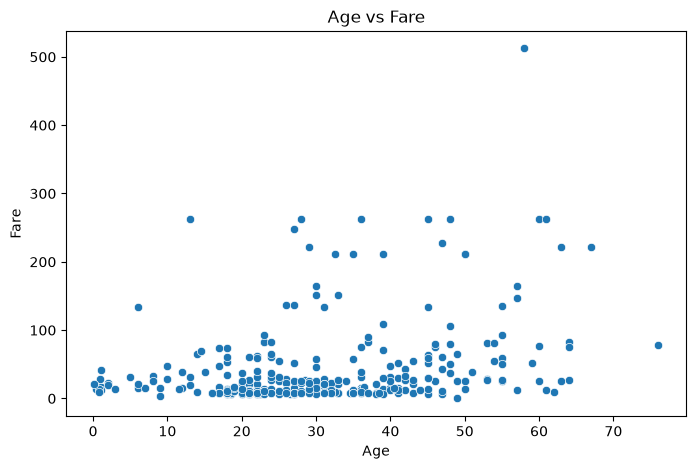

In [17]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="Age", y="Fare")

plt.title("Age vs Fare")
plt.show()

The scatter plot of Age vs Fare shows no clear linear trend — passengers of all ages paid a wide range of fares, with a small cluster of high-fare outliers scattered across ages rather than concentrated in one age group.

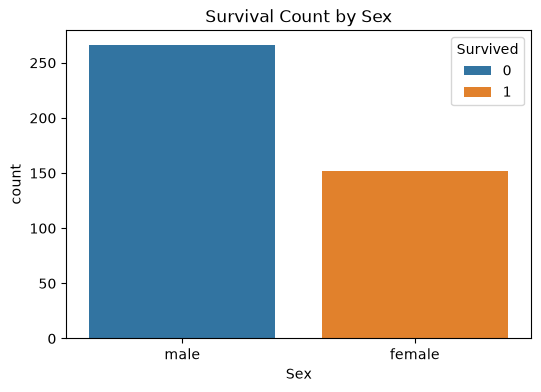

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Sex", hue="Survived")

plt.title("Survival Count by Sex")
plt.show()

The plot shows that survival differs strongly by sex, with female passengers 
having a higher survival rate compared with male passengers.

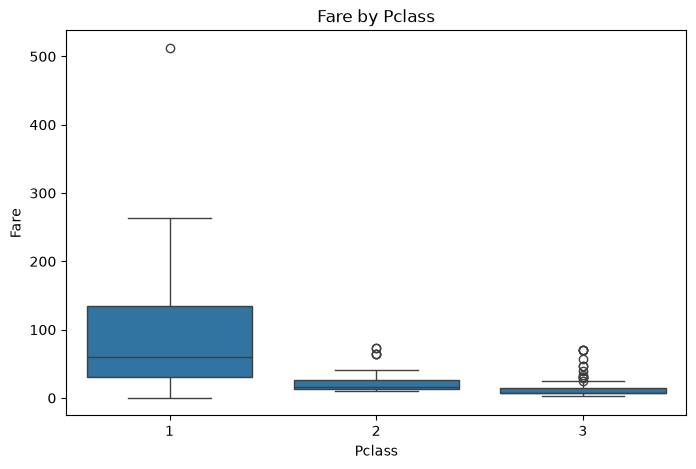

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Pclass", y="Fare")

plt.title("Fare by Pclass")
plt.show()

The grouped box plot shows Fare dropping sharply from 1st to 3rd class, with 1st class both paying the most on average and showing the widest spread and the most high-fare outliers — exactly what ticket class should predict.

## Step 2 — Correlation Matrix and Heatmap
Compute the correlation matrix for all numeric columns and visualize it as an annotated heatmap to see every pairwise relationship at once.

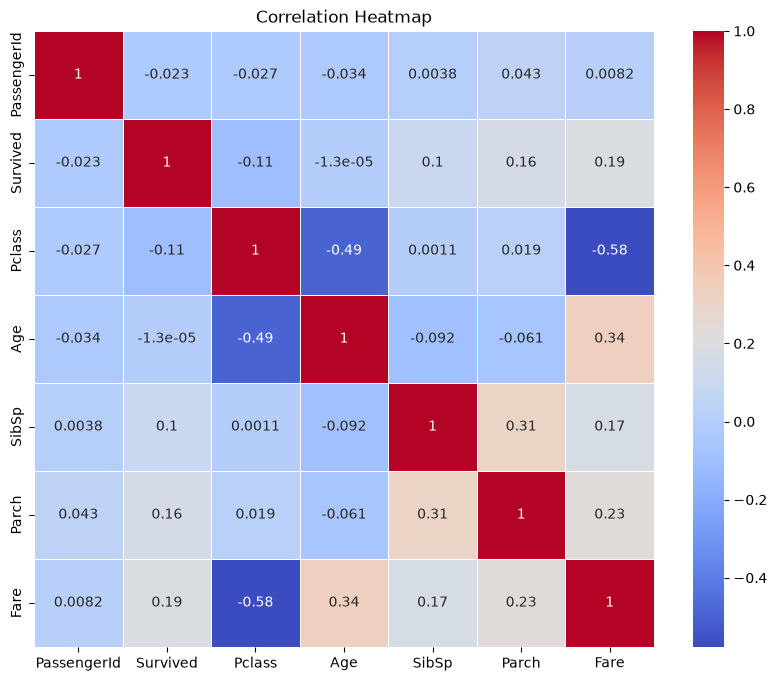

In [20]:
corr = df.corr(numeric_only=True)

corr

plt.figure(figsize=(10,8))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            linewidths=0.5)

plt.title("Correlation Heatmap")

plt.show()

The heatmap makes the pairwise relationships easy to scan visually rather than reading a raw numeric table. PassengerId correlates with nothing meaningfully, as expected — it is just a row identifier, not a real feature.

## Step 3 — Strongest Relationships and What They Might Mean for Modeling
Identify the two or three strongest relationships visible in the heatmap and state their implications for a future model.

**Strongest relationships observed:**

1. **Pclass and Fare (negative):** lower-numbered classes (1st class) are associated with higher fares. This is the strongest and most intuitive relationship in the matrix, since Pclass is essentially a proxy for how much was paid. A model would likely find these two features redundant to some degree.
2. **Fare and Survived (positive):** passengers who paid more had a somewhat higher chance of survival, consistent with 1st class passengers being prioritized during evacuation. This suggests Fare (or Pclass) could be a useful predictive feature for Survived.
3. **SibSp and Parch (positive):** the number of siblings/spouses aboard and the number of parents/children aboard move together, which makes sense — both describe family size. This hints that a combined "family size" feature could be more informative than the two separate columns.

**Reminder:** these are correlations, not causes. Paying more didn't directly cause survival — being in 1st class likely came with earlier access to lifeboats, which is the actual mechanism. EDA surfaces the pattern; it doesn't explain why it exists.

## The Pairplot
Use sns.pairplot() to scan every numeric variable against every other at once, colored by Survived, as a fast way to spot where to look closer.

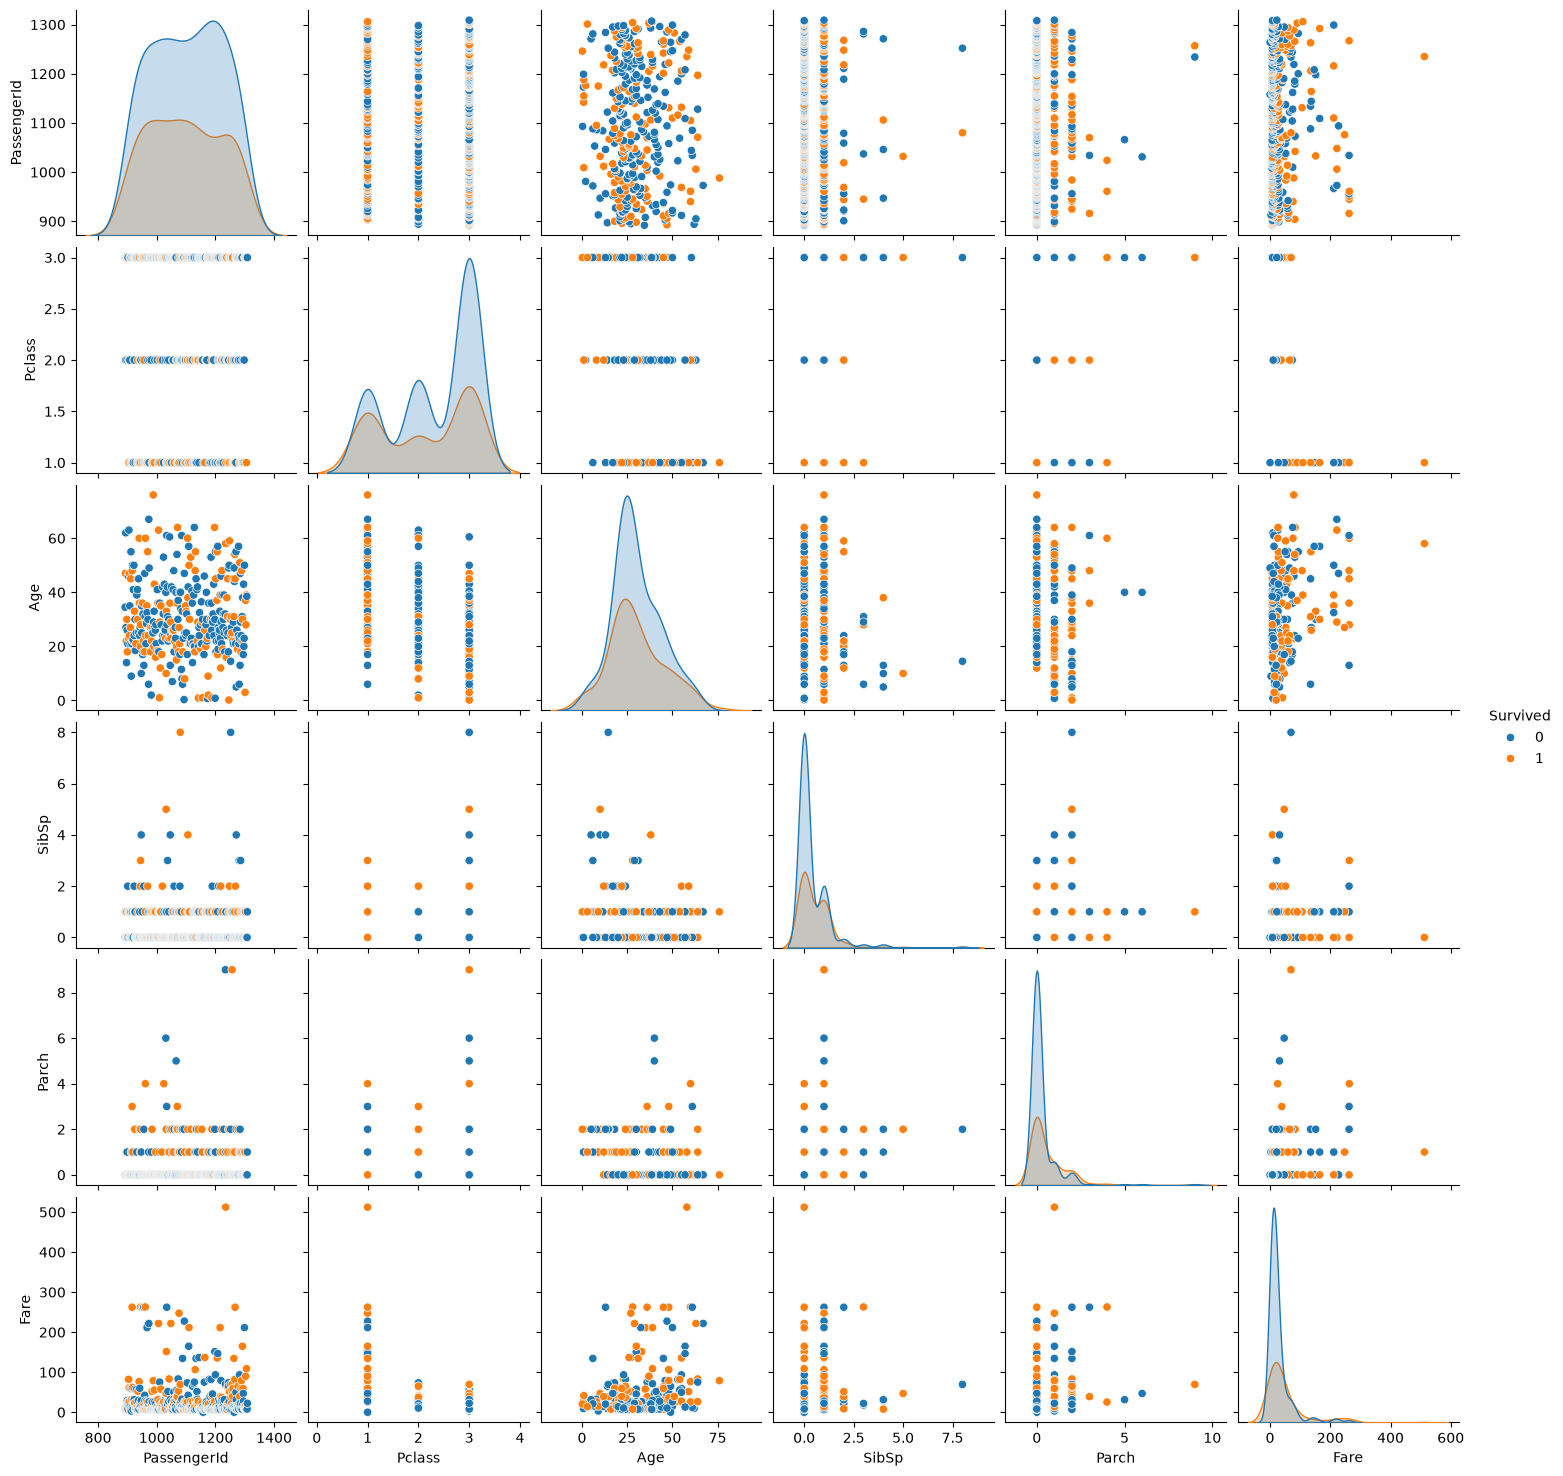

In [21]:
sns.pairplot(df, hue="Survived")

The pairplot's diagonal shows each variable's individual distribution split by survival, while the off-diagonal scatter plots show every pairwise relationship colored by outcome — useful for a quick visual scan of which variables separate the two Survived classes most clearly, such as Fare and Pclass.

## Step 4 — Assembling the Full EDA Narrative

Pulling the notebook together end-to-end:

- **Descriptive statistics:** 418 passengers, 12 columns; Age (86 missing), Fare (1 missing), and Cabin (327 missing, largely unusable) are the columns with data-quality issues to handle before modeling.
- **Univariate distributions:** Univariate distributions were inspected using descriptive statistics and missing-value analysis.. Pclass, Sex, Embarked, and Survived are categorical/discrete.
- **Outliers:** the Age vs Fare scatter plot and the Fare-by-Pclass box plot both show high-fare outliers concentrated in 1st class — plausible given ticket pricing, not likely data-entry errors.
- **Bivariate relationships:** Fare drops clearly across Pclass; Age vs Fare shows no strong linear pattern.
- **Correlation:** the heatmap and pairplot together point to Pclass/Fare and SibSp/Parch as the most related feature pairs, and Fare as the numeric variable most associated with Survived.

**Overall narrative:** ticket class and fare are the dataset's clearest story — they're strongly related to each other and both show some relationship with survival, while family-size features (SibSp, Parch) move together and could be combined. Age and Cabin need missing-value handling before they can be used reliably in a model.